# Point-level vs. full-image lens-distortion correction for AprilTag ROIs

This notebook tests the idea in `docs/ldc-point-correction.md`: keep the frame
raw, run the stock detector's threshold and contour stage inside each ROI (as the
CNN proposals would supply), then **undistort only samples of the detected
loop's edges**, fit straight lines in the corrected domain, intersect them for
corners, and read the bits through a **forward-distorted grid**. It compares
that with correcting the image first and then running the stock detector.

**Data**

- Calibration: `tools/ldc-calibration.json`, produced by `tools/ldc_calibrate.py`
  from `tools/ov5647_130_720p_calibration.mp4` (OV5647, 130° lens, 1280x720/60).
  Review images are in `tools/ldc-review.ov5647_130_720p/`.
- Real frame: `tools/test_post_ldc.png`, a raw 720p frame from the same lens
  with LDC off. It has a tag on the shelf and a tag cube on the desk.
- Synthetic frames, rendered through the same calibration, supply exact ground
  truth for corners and pose.

**Stock detector.** `ldcpt.nano_*` is a Python port of the production crop
decoder, `apps/tinytag_detect/third_party/aruco_nano`: box-filter threshold,
contours, `approxPolyDP` quads, a homography bit read, strict 36h11 decoding,
and `cornerSubPix`. `cv2.findContours` stands in for its visited-aware tracer.
OpenCV's `cv2.aruco` is an independent cross-check (`STOCK = "cv2"`).

**Running.** Use the `Python (ldc-point)` kernel, which is
`tools/ldc_point_correction/.venv`. The system Python's user site mixes
NumPy 2 with an OpenCV built for NumPy 1.

In [1]:
import json, math, time
from pathlib import Path
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
import ldcpt as L

cv2.setNumThreads(1)  # the Duo-S has one Linux core
pd.set_option("display.precision", 3)
ROOT = Path("..")
CAL = ROOT / "ldc-calibration.json"
REAL = ROOT / "test_post_ldc.png"
Path(".cache").mkdir(exist_ok=True)

# Fixed categorical order (validated palette): colour follows the method.
METHODS = ["raw_nocorr", "raw_corners", "full_remap", "full_remap_hw", "roi_remap",
           "loop_points", "loop_points_px"]
COLOR = dict(zip(METHODS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
                           "#008300", "#4a3aa7"]))
MARKER = dict(zip(METHODS, "osD^vPX"))
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6,
                     "lines.linewidth": 2, "font.size": 9})

## 1. Calibration and the model's invertible range

In [2]:
cal = json.loads(CAL.read_text())
cam = L.Camera.from_json(CAL)
ldc = cal["sophgo_vpss_ldc"]
print("image", cam.size, " views", cal["views"], " OpenCV RMS %.2f px" % cal["opencv_rms_px"])
print("K =\n", cam.K.round(2))
print("D (k1 k2 p1 p2 k3) =", cam.D.round(5))
print("HW one-ratio fit:", ldc)
print("model folds at ideal r = %.3f (normalized), raw radius %.0f px"
      % (cam.r_ideal_max, cam.fold_radius_px))
w, h = cam.size
corners = np.array([[0, 0], [w - 1, 0], [0, h - 1], [w - 1, h - 1]], float)
print("raw radius of the frame corners:", cam.raw_radius(corners).round(0))

image (1280, 720)  views 57  OpenCV RMS 1.58 px
K =
 [[739.46   0.   574.18]
 [  0.   736.63 309.71]
 [  0.     0.     1.  ]]
D (k1 k2 p1 p2 k3) = [-0.32721  0.12709  0.00202 -0.00053 -0.02532]
HW one-ratio fit: {'ratio': -250, 'center_x': -66, 'center_y': -50, 'view_ratio': 100, 'fitted_ratio_unclamped': -250.3411774838727, 'radial_fit_rms_px': 5.045039123631533}
model folds at ideal r = 1.496 (normalized), raw radius 686 px
raw radius of the frame corners: [652. 770. 705. 815.]


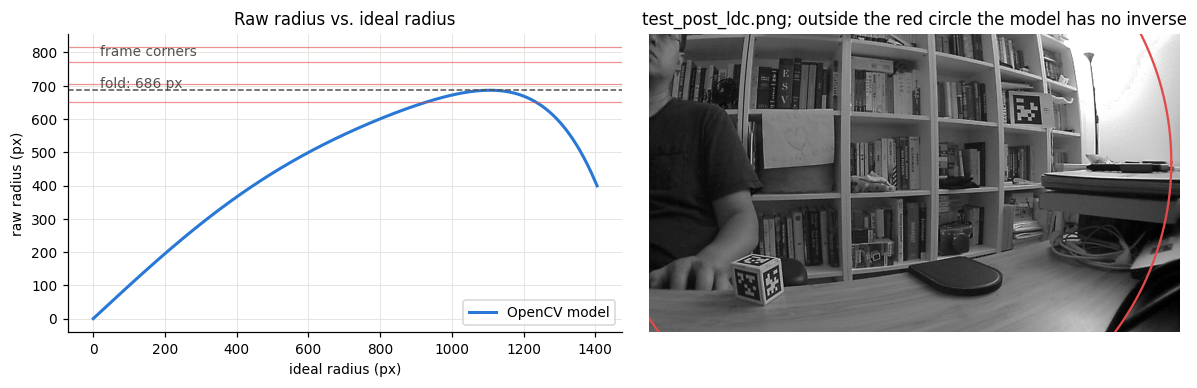

In [3]:
k1, k2, _, _, k3 = cam.D
r = np.linspace(0, 1.9, 400)
rd = r * (1 + k1 * r**2 + k2 * r**4 + k3 * r**6)
fx = cam.K[0, 0]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(r * fx, rd * fx, color="#2a78d6", label="OpenCV model")
src_hw, gain = L.hw_ldc_source(cam.size, ldc["ratio"], 0, 0)
ax[0].axhline(cam.fold_radius_px, color="#52514e", ls="--", lw=1)
ax[0].text(20, cam.fold_radius_px + 8, "fold: %.0f px" % cam.fold_radius_px, color="#52514e")
for rc in cam.raw_radius(corners):
    ax[0].axhline(rc, color="#e34948", lw=0.8, alpha=0.6)
ax[0].text(20, 790, "frame corners", color="#52514e")
ax[0].set(xlabel="ideal radius (px)", ylabel="raw radius (px)",
          title="Raw radius vs. ideal radius")
ax[0].legend(loc="lower right")
img = cv2.imread(str(REAL), cv2.IMREAD_GRAYSCALE)
ax[1].imshow(img, cmap="gray")
th = np.linspace(0, 2 * np.pi, 300)
ax[1].plot(cam.K[0, 2] + cam.fold_radius_px * np.cos(th), cam.K[1, 2] + cam.fold_radius_px * np.sin(th),
           color="#e34948", lw=1.5)
ax[1].set(xlim=(0, w), ylim=(h, 0), title="test_post_ldc.png; outside the red circle the model has no inverse")
ax[1].axis("off")
plt.tight_layout()

Past a raw radius of about 686 px, the fitted polynomial turns back on itself.
Three frame corners (705–815 px) lie outside that range. There, point
undistortion has no answer, and the full-image `cv::initUndistortRectifyMap` never
samples those pixels. Any method using this calibration inherits the limit, so
the synthetic scenes keep tags inside the fold. With the SW view (`newK = K`),
the corrected frame also excludes a band inside the fold, as the handover notes.

## 2. Methods

| method | where correction happens | corners from | bits read from |
|---|---|---|---|
| `raw_nocorr` | none (distortion ignored) | stock, raw ROI | raw quad homography |
| `raw_corners` | 4 detected corners, `undistortPoints` | stock + `cornerSubPix` on raw | raw quad homography |
| `full_remap` | whole frame, OpenCV model, `newK = K` (the SW LDC view) | stock on corrected ROI | corrected image |
| `full_remap_hw` | whole frame, per-pixel sim. of SG2000 one-ratio GDC mesh, read as a pinhole whose affine K is fitted near the center | stock on corrected ROI | corrected image |
| `roi_remap` | only the ROI's corrected-domain box, maps built per ROI | stock on corrected ROI | corrected ROI |
| **`loop_points`** | K samples per loop edge, refined to the subpixel edge crossing, then undistorted | lines fitted in the corrected domain, intersected | forward-distorted grid on the raw ROI |
| `loop_points_px` | same, but raw contour pixels (no subpixel step) | same | same |

All corners are compared in **ideal pixels** (the undistorted image with camera
matrix `K`). `loop_points` uses the stock detector's own candidate loops, so it
can find a tag only if `approxPolyDP` still yields a convex quad on the raw ROI.

## 3. Real frame: `test_post_ldc.png`

The stock detector runs on the whole frame, and each detected tag's box times 1.5
becomes the proposal ROI, as with `roi_expand = 1.5` in production.

In [4]:
rng = np.random.default_rng(0)
correctors = {"full_remap": L.opencv_corrector(cam), "full_remap_hw": L.hw_corrector(cam, ldc)}
base = L.nano_detect(img)
rois = {}
for d in sorted(base, key=lambda d: d.id):
    c = d.corners.mean(0)
    s = (d.corners.max(0) - d.corners.min(0)).max() * 1.5
    rois[d.id] = tuple(int(round(v)) for v in (max(c[0] - s / 2, 0), max(c[1] - s / 2, 0),
                                               min(c[0] + s / 2, w), min(c[1] + s / 2, h)))
print("tags:", {i: (r, "raw radius %.0f px" % cam.raw_radius(np.array([(r[0]+r[2])/2, (r[1]+r[3])/2])))
                for i, r in rois.items()})
print("cv2.aruco cross-check ids:", sorted(d.id for d in L.cv_aruco_detect(img)))

corrected = {}
for m, c in correctors.items():
    t = time.perf_counter(); corrected[m] = c.correct(img)
    print(f"{m}: full-frame remap {1e3 * (time.perf_counter() - t):.2f} ms on this host")

real = {}  # (method, id) -> Detection
real_ms = []
for m in METHODS:
    for i, roi in rois.items():
        t = time.perf_counter()
        ds = [d for d in L.run_method(m, cam, img, roi, rng, correctors=correctors,
                                      corrected=corrected) if d.id == i]
        real_ms.append(dict(method=m, id=i, ms=1e3 * (time.perf_counter() - t), found=bool(ds)))
        if ds:
            real[m, i] = ds[0]
pd.DataFrame(real_ms).pivot(index="method", columns="id", values="found").loc[METHODS]

tags: {0: ((858, 132, 964, 238), 'raw radius 359 px'), 1: ((232, 535, 362, 665), 'raw radius 401 px'), 2: ((180, 547, 295, 663), 'raw radius 448 px'), 3: ((186, 477, 327, 617), 'raw radius 397 px')}
cv2.aruco cross-check ids: [0, 1, 2, 3]
full_remap: full-frame remap 2.19 ms on this host
full_remap_hw: full-frame remap 2.23 ms on this host


id,0,1,2,3
method,,,,
raw_nocorr,True,True,True,True
raw_corners,True,True,True,True
full_remap,True,True,True,True
full_remap_hw,True,True,True,True
roi_remap,True,True,True,True
loop_points,True,True,True,True
loop_points_px,True,True,True,True


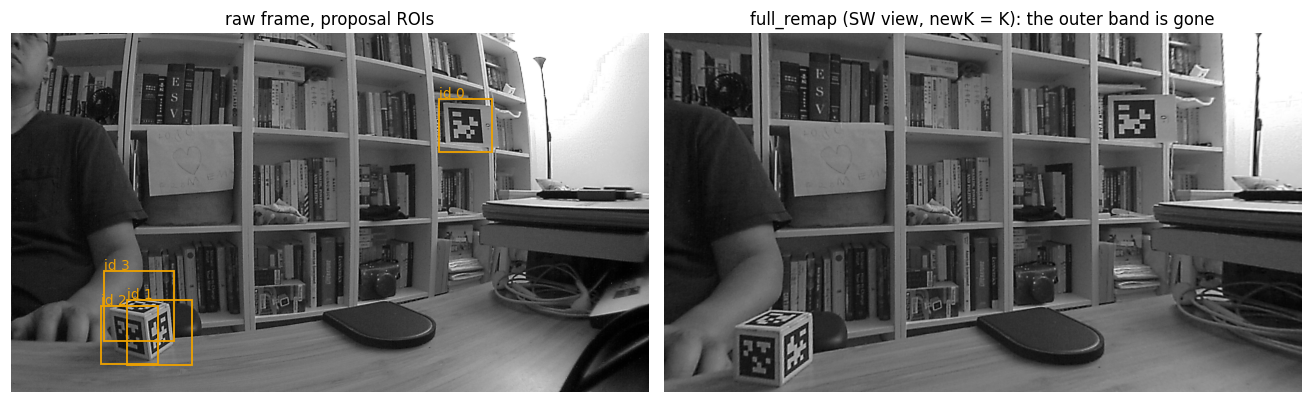

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
axs[0].imshow(img, cmap="gray")
for i, (x0, y0, x1, y1) in rois.items():
    axs[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="#eda100", lw=1.2))
    axs[0].text(x0, y0 - 4, f"id {i}", color="#eda100")
axs[0].set_title("raw frame, proposal ROIs"); axs[0].axis("off")
axs[1].imshow(corrected["full_remap"], cmap="gray")
axs[1].set_title("full_remap (SW view, newK = K): the outer band is gone"); axs[1].axis("off")
plt.tight_layout()

### 3.1 Corner agreement

There is no ground truth here, so each method's corners are compared with
`loop_points` in ideal pixels.

In [6]:
rows = []
for i in rois:
    ref = real["loop_points", i].corners
    for m in METHODS:
        if (m, i) not in real or m == "raw_nocorr":
            continue
        _, e = L.align(real[m, i].corners, ref)
        rows.append(dict(id=i, method=m, **{f"c{k}": e[k] for k in range(4)}, mean=e.mean()))
agree = pd.DataFrame(rows)
agree.pivot(index="method", columns="id", values="mean").loc[[m for m in METHODS[1:] if m != "loop_points"]]

id,0,1,2,3
method,,,,
raw_corners,0.436,0.260,0.748,3.058
full_remap,0.599,0.286,0.935,2.539
full_remap_hw,5.173,3.133,2.736,4.826
roi_remap,0.599,0.286,0.935,2.539
loop_points_px,1.221,1.583,1.295,1.924


### 3.2 Physical check: the cube's faces are perpendicular

Ids 1, 2 and 3 are on three faces of one cube, so their plane normals should be
90° apart in pairs. This needs no tag size: only rotation matters, so the object
points use a unit square. `ambiguity` is the ratio between the reprojection
errors of IPPE's two planar solutions. Near 1, the pose is poorly conditioned and
flips easily, which applies to the very oblique top face, id 3. Read its angles
with that in mind.

In [7]:
obj = np.array([[0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0]], float)
cube_rows = []
for m in METHODS:
    Rn, amb = {}, {}
    for i in (1, 2, 3):
        if (m, i) not in real:
            continue
        c = real[m, i].corners
        ref = real["loop_points", i].corners
        c, _ = L.align(c, ref)  # consistent corner order across methods
        n, rvs, tvs, errs = cv2.solvePnPGeneric(obj, c, cam.K, None, flags=cv2.SOLVEPNP_IPPE)
        errs = np.ravel(errs)
        Rn[i] = cv2.Rodrigues(rvs[0])[0][:, 2]
        amb[i] = errs[1] / max(errs[0], 1e-9) if len(errs) > 1 else np.nan
    row = dict(method=m)
    for a, b in [(1, 2), (1, 3), (2, 3)]:
        if a in Rn and b in Rn:
            row[f"{a}-{b} deg"] = math.degrees(math.acos(min(1, abs(Rn[a] @ Rn[b]))))
    row.update({f"ambiguity id{i}": amb.get(i) for i in (1, 2, 3)})
    cube_rows.append(row)
cube = pd.DataFrame(cube_rows).set_index("method")
cube["max |90-angle|"] = (cube.filter(like="deg") - 90).abs().max(axis=1)
cube

,1-2 deg,1-3 deg,2-3 deg,ambiguity id1,ambiguity id2,ambiguity id3,max |90-angle|
method,,,,,,,
raw_nocorr,79.601,82.583,53.732,2.781,136.002,1.085,36.268
raw_corners,89.472,70.491,64.779,48.650,29.919,1.029,25.221
full_remap,89.378,89.822,89.233,33.497,20.996,1.214,0.767
full_remap_hw,87.681,69.781,67.074,5.399,3.906,1.063,22.926
roi_remap,89.378,89.822,89.233,33.497,20.996,1.214,0.767
loop_points,89.575,89.744,89.369,12.495,8.334,1.878,0.631
loop_points_px,88.390,89.375,88.773,19.060,19.391,2.418,1.610


### 3.3 What `loop_points` does on one tag

**Left:** the raw ROI, with the refined edge samples, the loop_points corners
mapped back to raw, and the forward-distorted bit-sample grid. **Right:** the
same samples in the corrected (ideal) domain with the fitted lines. The straight
physical edges should make the corrected samples collinear.

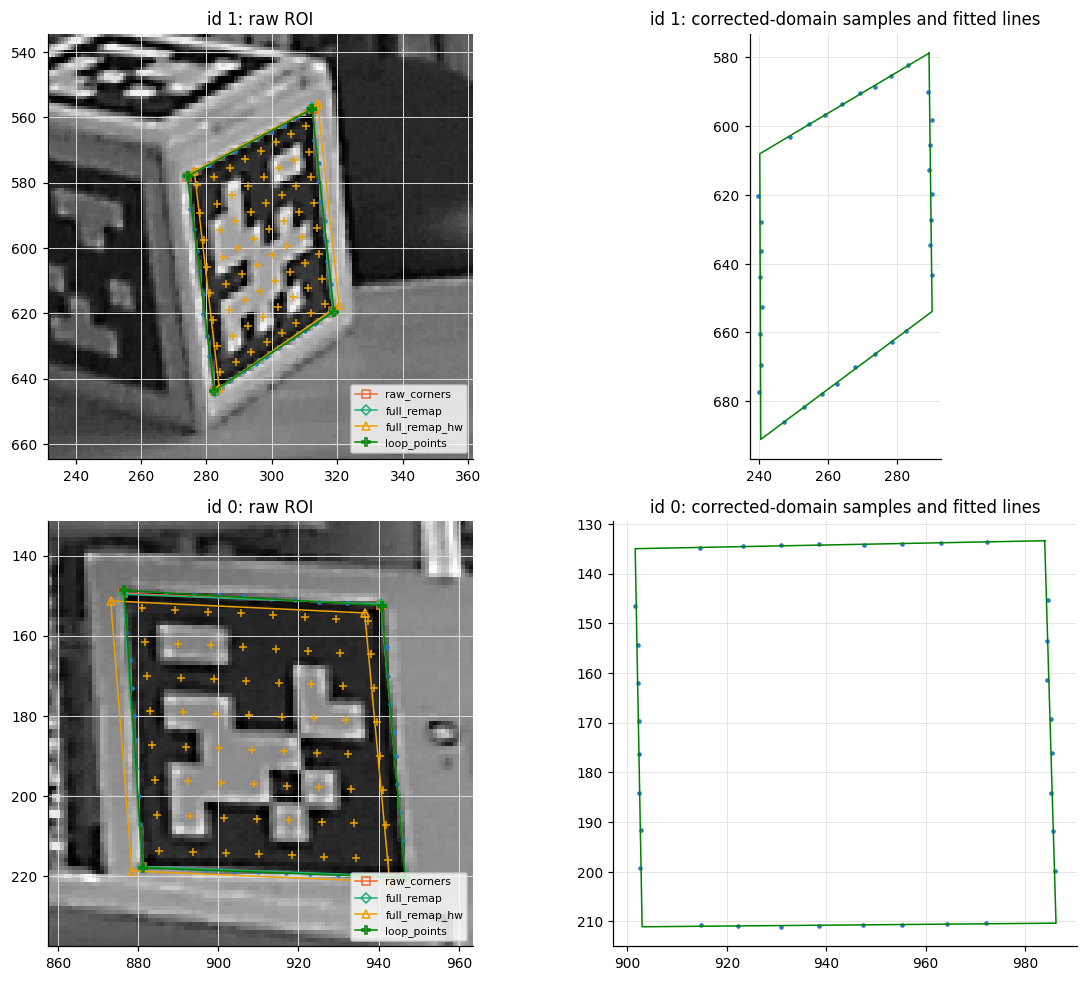

In [8]:
def show_loop(i, ax_raw, ax_ideal):
    x0, y0, x1, y1 = rois[i]
    d = real["loop_points", i]
    ax_raw.imshow(img[y0:y1, x0:x1], cmap="gray", extent=(x0 - .5, x1 - .5, y1 - .5, y0 - .5))
    for s in d.extra["raw_samples"]:
        ax_raw.plot(*s.T, ".", ms=4, color="#2a78d6")
    grid = L.fwd_grid_points(cam, d.corners, 1).reshape(-1, 2)
    ax_raw.plot(*grid.T, "+", ms=5, color="#eda100", mew=1)
    for m in ["raw_corners", "full_remap", "full_remap_hw", "loop_points"]:
        if (m, i) in real:
            c = cam.distort_ideal(real[m, i].corners)
            ax_raw.plot(*np.vstack([c, c[:1]]).T, marker=MARKER[m], ms=5, lw=1,
                        color=COLOR[m], label=m, fillstyle="none")
    ax_raw.set_title(f"id {i}: raw ROI"); ax_raw.legend(fontsize=7, loc="lower right")
    for k, s in enumerate(d.extra["ideal_samples"]):
        ax_ideal.plot(*s.T, ".", ms=4, color="#2a78d6")
    c = d.corners
    ax_ideal.plot(*np.vstack([c, c[:1]]).T, color=COLOR["loop_points"], lw=1)
    ax_ideal.set_aspect("equal"); ax_ideal.invert_yaxis()
    ax_ideal.set_title(f"id {i}: corrected-domain samples and fitted lines")

fig, axs = plt.subplots(2, 2, figsize=(11, 9))
show_loop(1, *axs[0]); show_loop(0, *axs[1])
plt.tight_layout()

### 3.4 Edge straightness: a real-data check of the calibration

This uses every contour pixel on each edge (`k_per_edge=None`), refined to
subpixel, and fits two lines to each edge:

- `raw_rms`: a straight line fitted in the raw image. It captures noise plus
  the curvature the lens adds.
- `model_rms`: a straight line fitted in the corrected domain, then mapped back
  through the distortion (a curve in raw pixels). This removes the curvature the
  calibration predicts.

Both residuals are in raw pixels, so they are comparable. Ideal pixels are
magnified about 1.2–1.3x at these radii. The number that matters is the edge
**bow**: the sagitta of a quadratic fit in raw pixels, against the bow the model
predicts for that edge.

In [9]:
pp_dense = L.PointParams(k_per_edge=None, margin=0.12, robust=False)
def resid_to(pts, l):
    return pts @ l[:2] + l[2]
def bow(raw):
    # sagitta of a quadratic fit across the chord, raw pixels
    d = raw[-1] - raw[0]; u = d / np.linalg.norm(d); n = np.array([-u[1], u[0]])
    s, t = (raw - raw[0]) @ u, (raw - raw[0]) @ n
    c = np.polyfit(s, t, 2)
    return float(-c[0] * (s.max() - s.min()) ** 2 / 4)
rows = []
for i, roi in rois.items():
    ds = [d for d in L.loop_points_detect(cam, img, roi, pp_dense) if d.id == i]
    if not ds:
        continue
    for k, (rs, ids) in enumerate(zip(ds[0].extra["raw_samples"], ds[0].extra["ideal_samples"])):
        lr = L.fit_line(rs, False)
        li = L.fit_line(ids, False)
        foot = ids - np.outer(resid_to(ids, li), li[:2])          # closest points on the ideal line
        model_curve = cam.distort_ideal(foot)                      # that line, in raw pixels
        rows.append(dict(id=i, edge=k, n=len(rs),
                         raw_rms=float(np.sqrt(np.mean(resid_to(rs, lr) ** 2))),
                         model_rms=float(np.sqrt(np.mean(np.sum((rs - model_curve) ** 2, 1)))),
                         bow_measured=bow(rs), bow_model=bow(model_curve)))
straight = pd.DataFrame(rows)
straight.round(3)

,id,edge,n,raw_rms,model_rms,bow_measured,bow_model
0,0,0,51,0.143,0.137,-0.147,-0.127
1,0,1,50,0.127,0.138,0.264,-0.050
2,0,2,51,0.154,0.175,-0.135,0.154
3,0,3,48,0.130,0.129,0.094,0.077
4,1,0,50,0.219,0.234,-0.068,0.134
5,1,1,32,0.213,0.216,-0.130,0.021
6,1,2,47,0.209,0.209,-0.123,-0.103
7,1,3,32,0.249,0.250,-0.004,-0.015
8,2,0,46,0.147,0.166,-0.076,0.132
9,2,1,39,0.229,0.242,-0.004,0.099


On this frame the check is **inconclusive**. After the corner margins, the tag
edges are only 32–51 px long and lie 360–450 px from the center, so the model
predicts at most about 0.15 px of bow. That is below the 0.13–0.41 px edge noise,
and `model_rms` is about equal to `raw_rms`. Validating the calibration where
the methods diverge needs a large tag, or long straight edges, at a raw radius
of 550–690 px.

## 4. Synthetic benchmark with ground truth

The renderer traces each supersampled (3x3) raw pixel through the inverse
calibration model onto paper planes carrying 36h11 tags. It adds clutter,
vignetting, blur and noise. Ground-truth corners are the analytic projections of
the 3D corners. Proposal ROIs take the true raw center with 8% jitter and 8%
scale noise, times 1.5. Two regimes are used:

- **normal**: 80 mm tags at 0.7–1.4 m (about 40–100 px), tilt up to ±25°;
- **large**: 120 mm tags at 0.35–0.7 m (about 120–250 px), where edge curvature
  inside one tag is largest.

normal 587 tags
large 129 tags


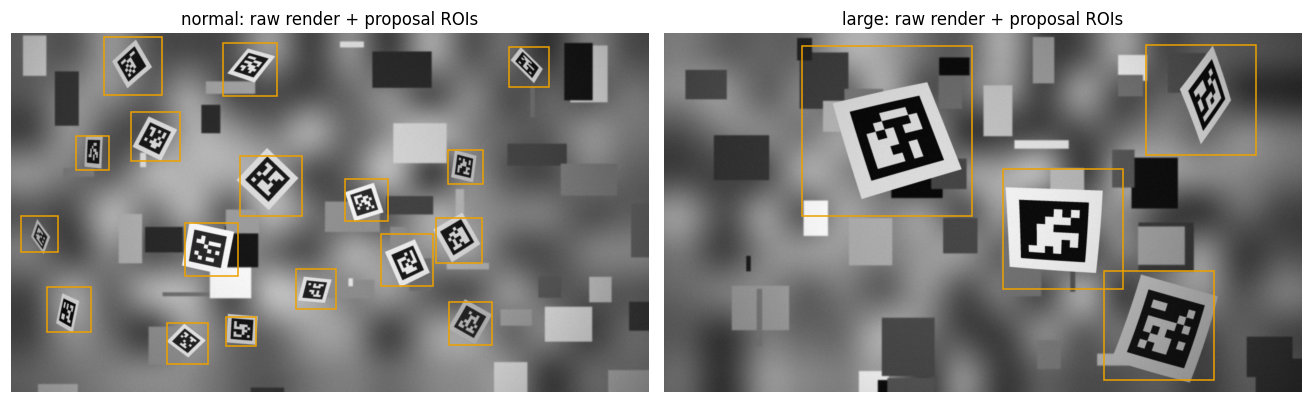

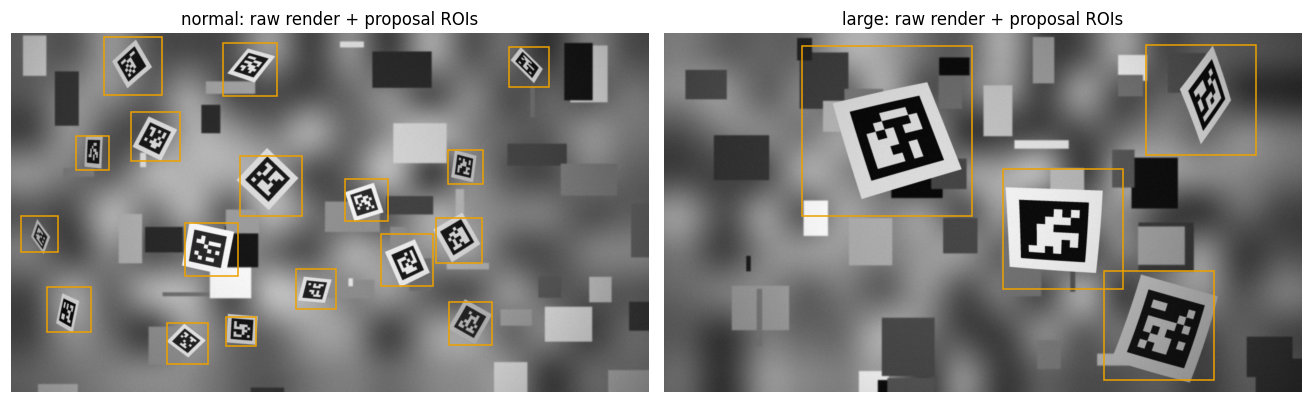

In [10]:
rend = L.Renderer(cam, 3, ".cache/render_ss3.npz")
REGIMES = {"normal": dict(size=0.08, dist=(0.7, 1.4)),
           "large": dict(size=0.12, dist=(0.35, 0.7), n_x=4, n_y=3)}
N_SCENES = 30
scenes = {}
for name, kw in REGIMES.items():
    rng = np.random.default_rng(1000 + len(name))
    scenes[name] = []
    for s in range(N_SCENES):
        tags, gts = L.make_scene(cam, rng, **kw)
        frame = rend.render(tags, rng)
        scenes[name].append((frame, gts, [L.proposal_roi(cam, g, rng) for g in gts]))
    print(name, sum(len(g) for _, g, _ in scenes[name]), "tags")

fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, name in zip(axs, scenes):
    frame, gts, rs = scenes[name][0]
    ax.imshow(frame, cmap="gray")
    for g, (x0, y0, x1, y1) in zip(gts, rs):
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="#eda100", lw=1))
    ax.set_title(f"{name}: raw render + proposal ROIs"); ax.axis("off")
plt.tight_layout()

In [11]:
def bench(scn, methods=METHODS, pp=None, stock="nano", corr=correctors, cam_=cam, seed=0):
    rng = np.random.default_rng(seed)
    out = []
    for f, (frame, gts, rs) in enumerate(scn):
        for r in L.run_methods(cam_, frame, gts, rs, rng, stock=stock, pp=pp, methods=methods,
                            
                               correctors=corr):
            r["frame"] = f
            out.append(r)
    return pd.DataFrame(out)

t = time.time()
res = pd.concat([bench(scenes[n]).assign(regime=n) for n in scenes], ignore_index=True)
print("benchmark %.1f s" % (time.time() - t))

def summary(df):
    g = df.groupby(["regime", "method"], sort=False)
    s = pd.DataFrame({
        "found %": 100 * g.found.mean(),
        "false ids": g.false_ids.sum(),
        "corner err mean": g.err_mean.mean(),
        "corner err p95": g.err_mean.quantile(0.95),
        "rot deg p50": g.rot_deg.median(),
        "rot deg p95": g.rot_deg.quantile(0.95),
        "t err % p50": g.t_pct.median(),
    })
    return s
summary(res)

benchmark 16.2 s


found %  false ids  corner err mean  corner err p95  \
regime method                                                                
normal raw_nocorr       97.104          0           63.606         221.141   
       raw_corners      96.934          0            0.521           2.305   
       full_remap       73.595          0            0.270           0.392   
       full_remap_hw    78.194          0            3.170           7.272   
       roi_remap        98.978          0            0.300           0.546   
       loop_points      98.807          0            0.166           0.622   
       loop_points_px   98.807          0            0.864           1.380   
large  raw_nocorr       96.124          0           72.937         213.847   
       raw_corners      96.899          0            0.310           0.507   
       full_remap       59.690          0            0.292           0.406   
       full_remap_hw    65.116          0            3.226          11.619   
       roi_remap       100.000          0            0.372           0.659   
       loop_points     100.000          0            0.138           0.238   
       loop_points_px   99.225          0            1.060           1.781   

                       rot deg p50  rot deg p95  t err % p50  
regime method                                                 
normal raw_nocorr           16.023       33.913       11.176  
       raw_corners           0.392        7.861        0.529  
       full_remap            0.331        2.040        0.587  
       full_remap_hw         1.744       23.172        1.330  
       roi_remap             0.356        1.545        0.645  
       loop_points           0.279        1.487        0.109  
       loop_points_px        1.038        7.668        1.729  
large  raw_nocorr           15.190       29.060       12.112  
       raw_corners           0.118        0.368        0.191  
       full_remap            0.141        0.514        0.182  
       full_remap_hw         1.372        7.344        0.932  
       roi_remap             0.155        0.478        0.226  
       loop_points           0.059        0.239        0.024  
       loop_points_px        0.354        0.955        0.773

### 4.1 By position in the frame

`full_remap` loses tags outside the SW view (`newK = K`). A method is plotted in
a bin only if it found at least 3 tags there.

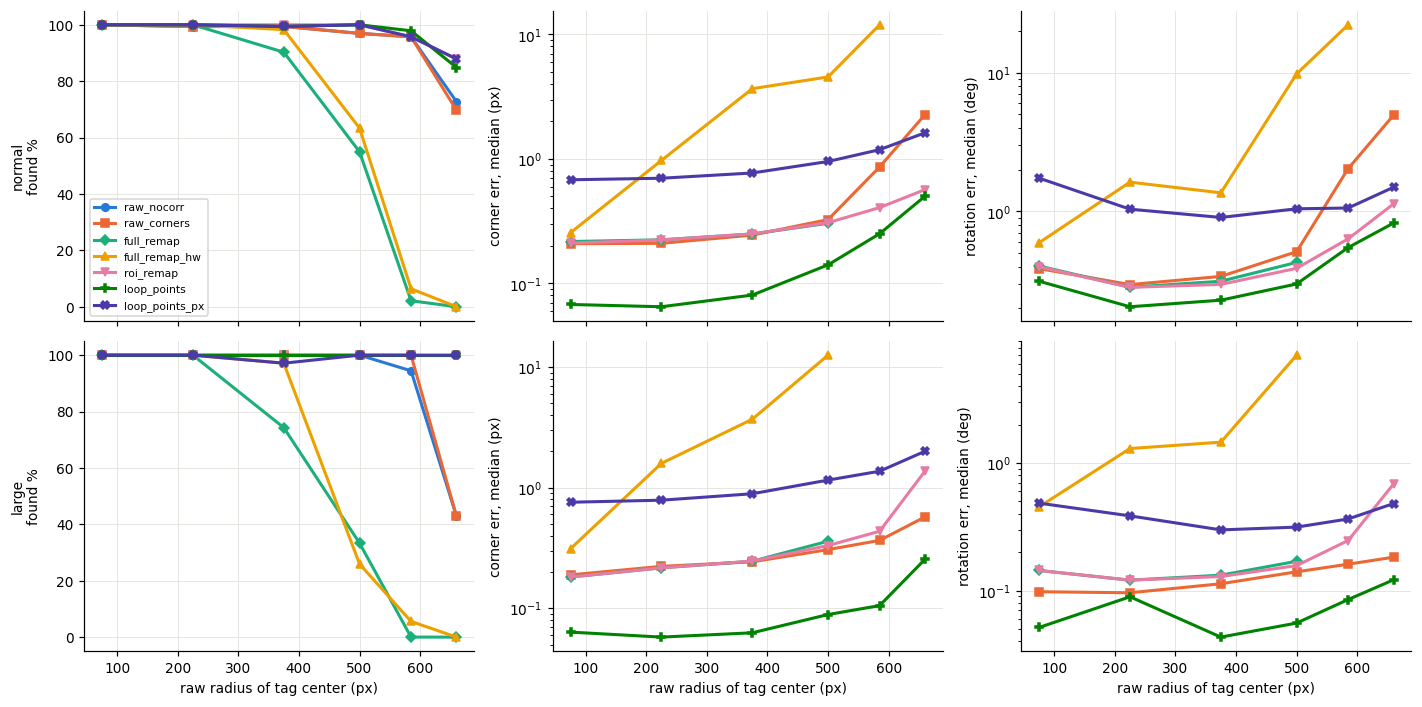

In [12]:
bins = [0, 150, 300, 450, 550, 620, 700]
res["rbin"] = pd.cut(res.radius, bins)
fig, axs = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
for row, regime in enumerate(scenes):
    d = res[res.regime == regime]
    for m in METHODS:
        dm = d[d.method == m]
        g = dm.groupby("rbin", observed=False)
        found = g.found.mean() * 100
        err = g.err_mean.median()
        rot = g.rot_deg.median()
        cnt = g.err_mean.count()
        x = [b.mid for b in found.index]
        kw = dict(color=COLOR[m], marker=MARKER[m], ms=5, label=m)
        axs[row, 0].plot(x, found.values, **kw)
        if m != "raw_nocorr":
            axs[row, 1].plot(x, err.where(cnt >= 3).values, **kw)
            axs[row, 2].plot(x, rot.where(cnt >= 3).values, **kw)
    axs[row, 0].set_ylabel(f"{regime}\nfound %")
    axs[row, 1].set_ylabel("corner err, median (px)"); axs[row, 1].set_yscale("log")
    axs[row, 2].set_ylabel("rotation err, median (deg)"); axs[row, 2].set_yscale("log")
for ax in axs[1]:
    ax.set_xlabel("raw radius of tag center (px)")
axs[0, 0].legend(fontsize=7, loc="lower left")
plt.tight_layout()

In [13]:
res.groupby(["regime", "rbin", "method"], observed=True).err_mean.median().unstack("method")[METHODS[1:]]

method             raw_corners  full_remap  full_remap_hw  roi_remap  \
regime rbin                                                            
large  (0, 150]          0.189       0.182          0.312      0.182   
       (150, 300]        0.223       0.217          1.592      0.217   
       (300, 450]        0.243       0.246          3.701      0.246   
       (450, 550]        0.307       0.360         12.588      0.332   
       (550, 620]        0.366         NaN         22.530      0.435   
       (620, 700]        0.573         NaN            NaN      1.375   
normal (0, 150]          0.208       0.217          0.256      0.211   
       (150, 300]        0.210       0.224          0.972      0.223   
       (300, 450]        0.244       0.249          3.667      0.250   
       (450, 550]        0.326       0.304          4.554      0.308   
       (550, 620]        0.862       0.374         11.945      0.406   
       (620, 700]        2.272         NaN            NaN      0.567   

method             loop_points  loop_points_px  
regime rbin                                     
large  (0, 150]          0.063           0.758  
       (150, 300]        0.058           0.788  
       (300, 450]        0.063           0.891  
       (450, 550]        0.089           1.157  
       (550, 620]        0.105           1.371  
       (620, 700]        0.255           2.006  
normal (0, 150]          0.068           0.680  
       (150, 300]        0.065           0.700  
       (300, 450]        0.081           0.771  
       (450, 550]        0.141           0.953  
       (550, 620]        0.251           1.186  
       (620, 700]        0.502           1.621

### 4.2 Samples per edge and corner margin

This sweeps `k_per_edge` and `margin` for `loop_points` on the large regime,
where curvature matters most. `None` means every contour pixel.

margin,0.0,0.1,0.2,0.3
K,,,,
3,0.729,0.155,0.204,0.226
4,0.587,0.191,0.186,0.316
6,0.467,0.171,0.181,0.290
8,0.355,0.159,0.180,0.250
12,0.195,0.153,0.173,0.165
16,0.158,0.162,0.164,0.176
all,0.103,0.116,0.143,0.121


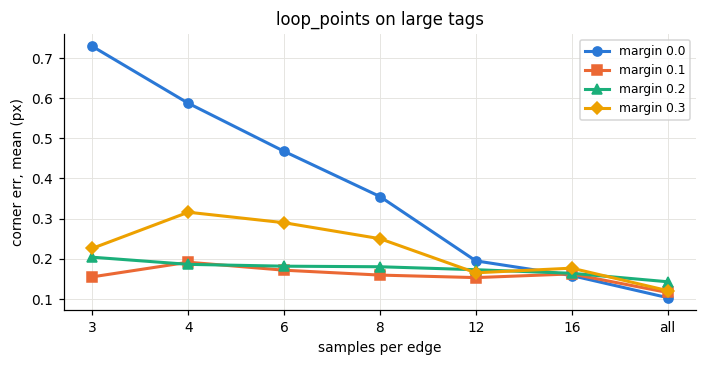

In [14]:
Ks, margins = [3, 4, 6, 8, 12, 16, None], [0.0, 0.1, 0.2, 0.3]
sub = scenes["large"][:15]
sweep = []
for k in Ks:
    for mg in margins:
        pp = L.PointParams(k_per_edge=k, margin=mg)
        d = bench(sub, methods=["loop_points"], pp=pp, corr={})
        sweep.append(dict(K="all" if k is None else str(k), margin=mg, found=100 * d.found.mean(),
                          err_mean=d.err_mean.mean(), err_p95=d.err_mean.quantile(0.95),
                          points=d.n_points.mean(), ms=d.ms.median()))
sweep = pd.DataFrame(sweep)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
mcol = dict(zip(margins, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
for mg in margins:
    s = sweep[sweep.margin == mg]
    ax.plot(range(len(Ks)), s.err_mean, marker="os^D"[margins.index(mg)], color=mcol[mg], label=f"margin {mg}")
ax.set_xticks(range(len(Ks)), [str(k) for k in sweep.K.unique()])
ax.set(xlabel="samples per edge", ylabel="corner err, mean (px)", title="loop_points on large tags")
ax.legend(fontsize=8)
plt.tight_layout()
sweep.pivot(index="K", columns="margin", values="err_mean").reindex(sweep.K.unique())

### 4.3 Stronger lens: detectability and decode

Scaling k1, k2 and k3 by 1.5 approximates a wider lens; its fold radius shrinks
accordingly. `loop_points_rawdec` keeps loop_points' corners but reads bits the
stock way, with a homography over the raw quad. That isolates the value of the
forward-distorted grid.

fold radius 512 px


found %  false ids  corner err mean  \
regime    method                                                    
lens x1.5 raw_corners          67.391          0            0.237   
          full_remap           56.522          0            0.246   
          roi_remap            97.826          0            0.452   
          loop_points          95.652          0            0.110   
          loop_points_rawdec   65.217          0            0.073   
          loop_points_px       95.652          0            1.171   

                              corner err p95  rot deg p50  rot deg p95  \
regime    method                                                         
lens x1.5 raw_corners                  0.318        0.112        0.245   
          full_remap                   0.312        0.089        0.391   
          roi_remap                    1.366        0.137        0.709   
          loop_points                  0.312        0.054        0.171   
          loop_points_rawdec           0.113        0.042        0.164   
          loop_points_px               2.095        0.255        1.056   

                              t err % p50  
regime    method                           
lens x1.5 raw_corners               0.123  
          full_remap                0.139  
          roi_remap                 0.142  
          loop_points               0.023  
          loop_points_rawdec        0.017  
          loop_points_px            0.567

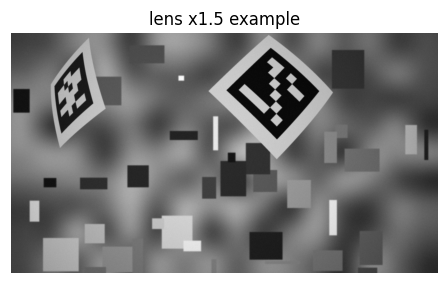

In [15]:
cam15 = L.Camera.from_json(CAL, dist_scale=1.5)
print("fold radius %.0f px" % cam15.fold_radius_px)
rend15 = L.Renderer(cam15, 3, ".cache/render_ss3_x15.npz")
rng = np.random.default_rng(7)
sc15 = []
for s in range(20):
    tags, gts = L.make_scene(cam15, rng, size=0.14, dist=(0.3, 0.6), n_x=4, n_y=3)
    sc15.append((rend15.render(tags, rng), gts, [L.proposal_roi(cam15, g, rng) for g in gts]))
corr15 = {"full_remap": L.opencv_corrector(cam15)}
m15 = ["raw_corners", "full_remap", "roi_remap", "loop_points", "loop_points_rawdec", "loop_points_px"]
res15 = bench(sc15, methods=m15, corr=corr15, cam_=cam15).assign(regime="lens x1.5")
fig, ax = plt.subplots(figsize=(5, 3)); ax.imshow(sc15[0][0], cmap="gray"); ax.axis("off")
ax.set_title("lens x1.5 example")
summary(res15)

## 5. Cost

These are host timings: x86, one OpenCV thread, and Python. Python loops
dominate `loop_points`, so treat these as relative magnitudes only. The
structural costs are more telling:

- `full_remap`: every pixel, every frame, with or without tags. On the Duo-S the
  measured cost is 25 ms (NEON mesh remap, idle) to 36 ms (live loop) per 720p
  frame. HW GDC adds about 7.5 ms of acquisition age and caps throughput.
- `roi_remap`: about 1.5–2x the ROI area of map math and remap per proposal.
- `loop_points`: about 4·K point undistortions (K = 8 gives 32) plus 64·9
  forward distortions for the bit grid, for each candidate loop.

In [16]:
cost = res.groupby(["regime", "method"], sort=False).agg(
    roi_ms_p50=("ms", "median"), frame_ms=("frame_ms", "median"), points=("n_points", "mean"))
tags_per_frame = res[res.method == "raw_corners"].groupby(["regime", "frame"]).size().groupby("regime").mean()
cost["per_frame_ms"] = [r.roi_ms_p50 * tags_per_frame[idx[0]] + r.frame_ms for idx, r in cost.iterrows()]
print("tags per frame:", tags_per_frame.round(1).to_dict())
cost

tags per frame: {'large': 4.3, 'normal': 19.6}


roi_ms_p50  frame_ms  points  per_frame_ms
regime method                                                    
normal raw_nocorr           0.781     0.000   0.000        15.279
       raw_corners          0.793     0.000   0.000        15.518
       full_remap           1.078     3.299   0.000        24.394
       full_remap_hw        1.106     3.272   0.000        24.913
       roi_remap            2.128     0.000   0.000        41.647
       loop_points          3.568     0.000  31.914        69.820
       loop_points_px       1.998     0.000  32.000        39.100
large  raw_nocorr           5.049     0.000   0.000        21.709
       raw_corners          5.135     0.000   0.000        22.081
       full_remap           3.672     3.306   0.000        19.097
       full_remap_hw        3.664     3.285   0.000        19.040
       roi_remap           12.705     0.000   0.000        54.630
       loop_points          7.996     0.000  31.884        34.383
       loop_points_px       7.522     0.000  32.000        32.344

## 6. Is `loop_points` equivalent to region-level correction?

Sections 3–5 show similar accuracy. Equivalence is a stronger claim: in the
limit, the corners should agree tag by tag, and any remaining difference should
be explained by noise rather than by the method. Three tests follow.

- **A. Convergence.** Identical geometry and shading are rendered clean at 5x5
  supersampling, and noise is added in steps. If the methods are consistent,
  every error should fall toward a common floor as noise goes to zero. The
  floor includes 8-bit quantization and the renderer's own error, measured by
  comparing 3x3 with 5x5 supersampling. A blur sweep at zero noise separates
  estimator bias from noise.
- **B. Paired per-tag differences.** For tags found by both methods, the corner
  difference is split into a radial part (toward or away from the principal
  point) and a tangential part. A systematic mismatch in how the distortion is
  applied would appear as a nonzero **radial** mean. Independent estimators would
  show RMS differences near `sqrt(rms_a² + rms_b²)`; strongly correlated errors
  mean the methods measure the same thing.
- **C. Same corner estimator in both domains.** `roi_remap_edgefit` remaps the
  ROI exactly as `roi_remap` does, then runs `loop_points`' estimator (subpixel
  edge samples, line fits, intersections, grid decode) on the corrected crop.
  Against `loop_points`, the only difference is where the edges are measured:
  raw pixels with point undistortion, or remapped pixels.

In [17]:
EQ_METHODS = ["full_remap", "roi_remap", "roi_remap_edgefit", "loop_points"]
EQ_COLOR = {"full_remap": COLOR["full_remap"], "roi_remap": COLOR["roi_remap"],
            "roi_remap_edgefit": "#4a3aa7", "loop_points": COLOR["loop_points"]}
EQ_MARKER = {"full_remap": "D", "roi_remap": "v", "roi_remap_edgefit": "s", "loop_points": "P"}

rend5 = L.Renderer(cam, 5, ".cache/render_ss5.npz")
conv_scenes = {}  # regime -> list of (tags, gts, rois, render seed)
for name, kw in REGIMES.items():
    rng = np.random.default_rng(5000 + len(name))
    conv_scenes[name] = []
    for s in range(12):
        tags, gts = L.make_scene(cam, rng, **kw)
        conv_scenes[name].append((tags, gts, [L.proposal_roi(cam, g, rng) for g in gts],
                                  int(rng.integers(1 << 31))))

def conv_run(renderer, blur, noise, methods=EQ_METHODS):
    out = []
    for name, lst in conv_scenes.items():
        for f, (tags, gts, rs, seed) in enumerate(lst):
            clean = renderer.render(tags, np.random.default_rng(seed), noise=0, blur=blur,
                                    quantize=False)
            noisy = clean + np.random.default_rng(seed + 1).normal(0, noise, clean.shape) if noise else clean
            frame = np.clip(np.rint(noisy), 0, 255).astype(np.uint8)
            for r in L.run_methods(cam, frame, gts, rs, np.random.default_rng(0), methods=methods,
                                   correctors=correctors):
                r.update(regime=name, frame=f, noise=noise, blur=blur)
                out.append(r)
    return out

t = time.time()
conv = pd.DataFrame([r for n in [0, 0.5, 1, 2, 4] for r in conv_run(rend5, 0.6, n)]
                    + [r for b in [0.35, 1.0] for r in conv_run(rend5, b, 0)])
conv_ss3 = pd.DataFrame(conv_run(rend, 0.6, 0))
print("convergence runs %.0f s; tags per condition:" % (time.time() - t),
      conv[(conv.noise == 0) & (conv.blur == 0.6) & (conv.method == "loop_points")].groupby("regime").size().to_dict())

convergence runs 66 s; tags per condition: {'large': 53, 'normal': 231}


### 6A. Convergence as noise goes to zero (blur 0.6 px)

method        full_remap  roi_remap  roi_remap_edgefit  loop_points
regime noise                                                       
large  0.0         0.246      0.275              0.064        0.079
       0.5         0.245      0.277              0.065        0.080
       1.0         0.245      0.275              0.067        0.082
       2.0         0.249      0.284              0.078        0.088
       4.0         0.260      0.303              0.098        0.113
normal 0.0         0.259      0.284              0.107        0.126
       0.5         0.271      0.285              0.107        0.127
       1.0         0.259      0.287              0.108        0.129
       2.0         0.261      0.296              0.113        0.134
       4.0         0.269      0.307              0.131        0.150

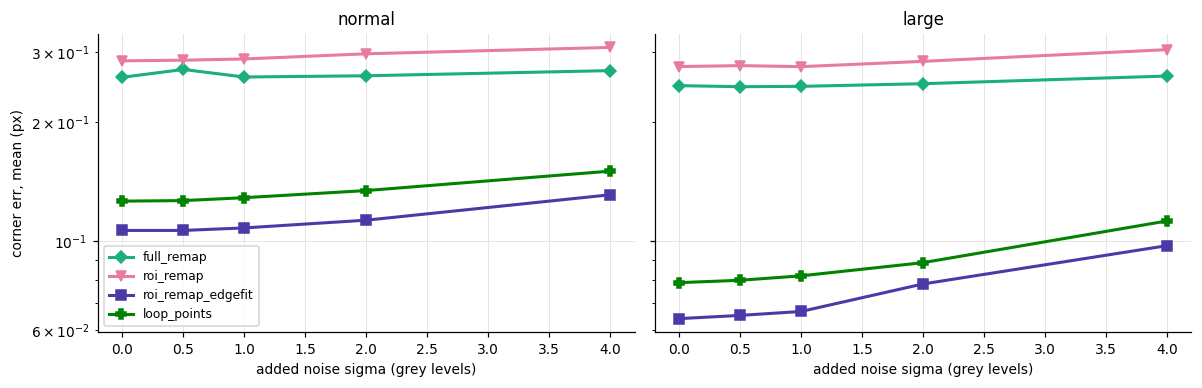

In [18]:
d = conv[conv.blur == 0.6]
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, regime in zip(axs, REGIMES):
    for m in EQ_METHODS:
        g = d[(d.regime == regime) & (d.method == m)].groupby("noise").err_mean.mean()
        ax.plot(g.index, g.values, marker=EQ_MARKER[m], color=EQ_COLOR[m], ms=6, label=m)
    ax.set(xlabel="added noise sigma (grey levels)", title=regime, yscale="log")
axs[0].set_ylabel("corner err, mean (px)")
axs[0].legend(fontsize=8)
plt.tight_layout()
d.groupby(["regime", "noise", "method"]).err_mean.mean().unstack("method")[EQ_METHODS]

In [19]:
# Zero noise: blur sweep, and the renderer floor (3x3 vs 5x5 supersampling at blur 0.6)
z = conv[conv.noise == 0].groupby(["regime", "blur", "method"]).err_mean.mean().unstack("method")[EQ_METHODS]
floor = pd.concat({"ss 3x3": conv_ss3.groupby(["regime", "method"]).err_mean.mean().unstack("method"),
                   "ss 5x5": conv[(conv.noise == 0) & (conv.blur == 0.6)]
                   .groupby(["regime", "method"]).err_mean.mean().unstack("method")})[EQ_METHODS]
display(z.rename_axis(columns="zero noise: mean corner err (px)"))
display(floor.rename_axis(columns="renderer floor check, blur 0.6"))

zero noise: mean corner err (px)  full_remap  roi_remap  roi_remap_edgefit  \
regime blur                                                                  
large  0.35                            0.201      0.239              0.074   
       0.60                            0.246      0.275              0.064   
       1.00                            0.376      0.442              0.122   
normal 0.35                            0.215      0.233              0.089   
       0.60                            0.259      0.284              0.107   
       1.00                            0.377      0.448              0.193   

zero noise: mean corner err (px)  loop_points  
regime blur                                    
large  0.35                             0.103  
       0.60                             0.079  
       1.00                             0.073  
normal 0.35                             0.115  
       0.60                             0.126  
       1.00                             0.207

renderer floor check, blur 0.6  full_remap  roi_remap  roi_remap_edgefit  \
       regime                                                              
ss 3x3 large                         0.249      0.294              0.079   
       normal                        0.277      0.290              0.116   
ss 5x5 large                         0.246      0.275              0.064   
       normal                        0.259      0.284              0.107   

renderer floor check, blur 0.6  loop_points  
       regime                                
ss 3x3 large                          0.091  
       normal                         0.138  
ss 5x5 large                          0.079  
       normal                         0.126

**A, reading.** No method converges to zero, and they do not share a floor.
With zero noise, the edge-fit estimators stay at 0.06–0.13 px and the stock
`cornerSubPix` paths at 0.25–0.28 px. Going from 3x3 to 5x5 supersampling
changes the numbers by at most 0.02 px, so the floors are **estimator bias**,
not renderer error. Noise up to sigma 4 adds only 0.02–0.04 px. Blur separates
the estimators: from blur 0.35 to 1.0 px, stock error grows from about 0.2 to
0.38–0.45 px, because rounded corners bias `cornerSubPix`. The edge fit stays
within 0.07–0.12 px on large tags. On small tags it grows to 0.21 px, because
the edge profile starts to include neighbouring data cells.

### 6B. Paired per-tag differences

Each row pairs `a` with `b` on the tags both found. The columns are:

- `radial` and `tangential`: mean difference with a 95% CI;
- `median`, `p95` and `max |diff|`, and `rms diff`: the size of the per-corner
  difference. RMS is dominated by a few tags near the fold, so read the median
  first;
- `rms if indep.`: the RMS difference expected if the two error vectors were
  independent;
- `err corr`: the correlation of the two methods' error vectors;
- `a better by`: the mean of `|err_b| - |err_a|` with a 95% CI (positive means
  `a` is more accurate).

In [21]:
pp0 = cam.K[:2, 2]
def paired(df, a, b):
    key = ["regime", "frame", "id"]
    A = df[(df.method == a) & df.found].set_index(key)
    B = df[(df.method == b) & df.found].set_index(key)
    common = A.index.intersection(B.index)
    rad, tan, dn, ea, eb, va, vb = [], [], [], [], [], [], []
    for k in common:
        ca, cb, gt = A.loc[k, "corners"], B.loc[k, "corners"], A.loc[k, "gt"]
        u = (gt - pp0) / np.linalg.norm(gt - pp0, axis=1, keepdims=True)
        v = np.c_[-u[:, 1], u[:, 0]]
        diff = ca - cb
        rad += list(np.sum(diff * u, 1)); tan += list(np.sum(diff * v, 1))
        dn += list(np.linalg.norm(diff, axis=1))
        ea += list(np.linalg.norm(ca - gt, axis=1)); eb += list(np.linalg.norm(cb - gt, axis=1))
        va.append((ca - gt).ravel()); vb.append((cb - gt).ravel())
    rad, tan, dn, ea, eb = map(np.array, (rad, tan, dn, ea, eb))
    va, vb = np.concatenate(va), np.concatenate(vb)
    ci = lambda x: 1.96 * x.std(ddof=1) / math.sqrt(len(x))
    gain = eb - ea
    return {"a": a, "b": b, "tags": len(common),
            "radial": f"{rad.mean():+.3f} ± {ci(rad):.3f}",
            "tangential": f"{tan.mean():+.3f} ± {ci(tan):.3f}",
            "median |diff|": np.median(dn), "p95 |diff|": np.quantile(dn, 0.95),
            "max |diff|": dn.max(), "rms diff": math.sqrt(np.mean(dn**2)),
            "rms if indep.": math.sqrt(np.mean(ea**2) + np.mean(eb**2)),
            "err corr": np.corrcoef(va, vb)[0, 1],
            "a better by": f"{gain.mean():+.3f} ± {ci(gain):.3f}"}

eq_main = pd.concat([bench(scenes[n], methods=["roi_remap_edgefit"]).assign(regime=n) for n in scenes],
                    ignore_index=True)
main_eq = pd.concat([res, eq_main], ignore_index=True)
PAIRS = [("loop_points", "roi_remap_edgefit"), ("loop_points", "roi_remap"),
         ("loop_points", "full_remap"), ("roi_remap", "full_remap")]
tables = {}
for label, df in [("noise 0, blur 0.6, ss5", conv[(conv.noise == 0) & (conv.blur == 0.6)]),
                  ("noise 2, blur 0.6, ss5", conv[(conv.noise == 2) & (conv.blur == 0.6)]),
                  ("main benchmark (noise 2, ss3)", main_eq)]:
    tables[label] = pd.DataFrame([paired(df, a, b) for a, b in PAIRS]).set_index(["a", "b"])
paired_tbl = pd.concat(tables)
paired_tbl

tags  \
                              a           b                         
noise 0, blur 0.6, ss5        loop_points roi_remap_edgefit   278   
                                          roi_remap           278   
                                          full_remap          190   
                              roi_remap   full_remap          191   
noise 2, blur 0.6, ss5        loop_points roi_remap_edgefit   278   
                                          roi_remap           278   
                                          full_remap          190   
                              roi_remap   full_remap          191   
main benchmark (noise 2, ss3) loop_points roi_remap_edgefit   709   
                                          roi_remap           708   
                                          full_remap          508   
                              roi_remap   full_remap          509   

                                                                     radial  \
                              a           b                                   
noise 0, blur 0.6, ss5        loop_points roi_remap_edgefit  +0.014 ± 0.010   
                                          roi_remap          +0.039 ± 0.016   
                                          full_remap         +0.060 ± 0.023   
                              roi_remap   full_remap         +0.027 ± 0.019   
noise 2, blur 0.6, ss5        loop_points roi_remap_edgefit  +0.015 ± 0.011   
                                          roi_remap          +0.041 ± 0.018   
                                          full_remap         +0.060 ± 0.023   
                              roi_remap   full_remap         +0.026 ± 0.019   
main benchmark (noise 2, ss3) loop_points roi_remap_edgefit  +0.012 ± 0.008   
                                          roi_remap          +0.030 ± 0.014   
                                          full_remap         +0.047 ± 0.017   
                              roi_remap   full_remap         +0.019 ± 0.013   

                                                                 tangential  \
                              a           b                                   
noise 0, blur 0.6, ss5        loop_points roi_remap_edgefit  -0.003 ± 0.007   
                                          roi_remap          -0.009 ± 0.017   
                                          full_remap         +0.001 ± 0.015   
                              roi_remap   full_remap         +0.003 ± 0.006   
noise 2, blur 0.6, ss5        loop_points roi_remap_edgefit  -0.000 ± 0.008   
                                          roi_remap          +0.000 ± 0.019   
                                          full_remap         +0.002 ± 0.015   
                              roi_remap   full_remap         +0.004 ± 0.006   
main benchmark (noise 2, ss3) loop_points roi_remap_edgefit  +0.001 ± 0.009   
                                          roi_remap          +0.002 ± 0.014   
                                          full_remap         +0.006 ± 0.012   
                              roi_remap   full_remap         +0.001 ± 0.006   

                                                             median |diff|  \
                              a           b                                  
noise 0, blur 0.6, ss5        loop_points roi_remap_edgefit          0.069   
                                          roi_remap                  0.231   
                                          full_remap                 0.212   
                              roi_remap   full_remap                 0.000   
noise 2, blur 0.6, ss5        loop_points roi_remap_edgefit          0.072   
                                          roi_remap                  0.238   
                                          full_remap                 0.216   
                              roi_remap   full_remap                 0.000   
main benchmark (noise 2, ss3) loop_points roi_remap_edgefit          0.085   
                      

**B, reading.**

- **Geometry agrees.** The radial difference between `loop_points` and
  `roi_remap_edgefit` is +0.012–0.015 ± 0.01 px, and the tangential difference
  is zero. Undistorting points and remapping pixels place the same edge at the
  same corrected position to about 0.01 px, which is the consistency the design
  note relies on.
- **Per-tag values do not.** Their error vectors correlate at only about 0.38.
  The RMS difference (0.21 px at zero noise) is close to the 0.26 px expected
  for independent estimators. The median per-tag difference is 0.05–0.07 px
  mid-field but rises to 0.17 px at a 585 px radius and 0.38 px at 660 px, next
  to the fold (plot below). The two are different estimators of one quantity,
  not one computation done in a different order.
- **`roi_remap` and `full_remap` are identical on 95% of tags,** because they
  feed the same pixels to the same detector. The two paths diverge only on a
  few outlier tags.
- **Accuracy ranking.** The edge fit in the corrected domain beats
  `loop_points` by 0.023–0.037 ± 0.010 px. `loop_points` beats stock
  `roi_remap` by 0.15–0.16 px.

### 6C. Same estimator, both domains: main benchmark

In [22]:
s = summary(main_eq[main_eq.method.isin(["roi_remap", "roi_remap_edgefit", "loop_points"])])
s

found %  false ids  corner err mean  corner err p95  \
regime method                                                                   
normal roi_remap           98.978          0            0.300           0.546   
       loop_points         98.807          0            0.166           0.622   
large  roi_remap          100.000          0            0.372           0.659   
       loop_points        100.000          0            0.138           0.238   
normal roi_remap_edgefit   99.319          0            0.130           0.374   
large  roi_remap_edgefit  100.000          0            0.103           0.255   

                          rot deg p50  rot deg p95  t err % p50  
regime method                                                    
normal roi_remap                0.356        1.545        0.645  
       loop_points              0.279        1.487        0.109  
large  roi_remap                0.155        0.478        0.226  
       loop_points              0.059        0.239        0.024  
normal roi_remap_edgefit        0.241        1.011        0.115  
large  roi_remap_edgefit        0.063        0.234        0.026

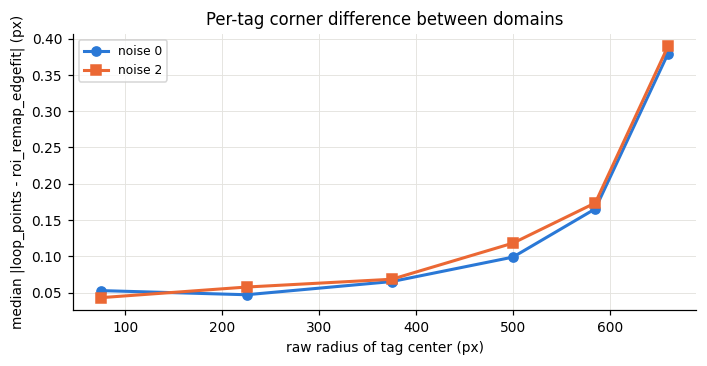

In [23]:
# Where do the two domains diverge? Median |diff| by radius, noise 0 vs noise 2.
fig, ax = plt.subplots(figsize=(6.5, 3.4))
bins = [0, 150, 300, 450, 550, 620, 700]
for (label, df), mk, col in zip([("noise 0", conv[(conv.noise == 0) & (conv.blur == 0.6)]),
                                  ("noise 2", conv[(conv.noise == 2) & (conv.blur == 0.6)])],
                                 "os", ["#2a78d6", "#eb6834"]):
    key = ["regime", "frame", "id"]
    A = df[(df.method == "loop_points") & df.found].set_index(key)
    B = df[(df.method == "roi_remap_edgefit") & df.found].set_index(key)
    common = A.index.intersection(B.index)
    r = A.loc[common, "radius"].values
    dd = np.array([np.linalg.norm(A.loc[k, "corners"] - B.loc[k, "corners"], axis=1).mean() for k in common])
    g = pd.Series(dd).groupby(pd.cut(r, bins), observed=True).median()
    ax.plot([b.mid for b in g.index], g.values, marker=mk, color=col, label=label)
ax.set(xlabel="raw radius of tag center (px)", ylabel="median |loop_points - roi_remap_edgefit| (px)",
       title="Per-tag corner difference between domains")
ax.legend(fontsize=8)
plt.tight_layout()

**C, reading.** With the same estimator, measuring in the corrected domain
matches or slightly beats measuring in the raw domain. `roi_remap_edgefit`
gives 0.130 / 0.103 px (normal / large), against 0.166 / 0.138 px for
`loop_points`, with similar rotation error and recall. The accuracy advantage of
`loop_points` over stock `roi_remap` (0.30 / 0.37 px) therefore comes almost
entirely from the edge-fit corner estimator, not from correcting points instead
of pixels. The raw domain loses most near the fold, where each raw pixel spans
several ideal pixels. That likely amplifies edge-localization error once it is
mapped through the inverse; this was not tested separately.

**Verdict.** `loop_points` is **not** mathematically equivalent to
`full_remap` or `roi_remap`. It is geometrically consistent with them (radial
bias of about 0.01 px), and with the same corner estimator it is about as
accurate as region-level correction: within 0.02–0.04 px on average, worse near
the fold. Its real advantage is cost. It needs no pixel remapping, and the edge
fit does most of the accuracy work, which could equally run on a remapped
ROI.

## 7. Findings

**Real frame** (`test_post_ldc.png`; 4 tags at raw radius 359–448 px)

- Every method found all four tags; `cv2.aruco` agrees on the ids.
- Relative to `loop_points`, `raw_corners`, `full_remap` and `roi_remap` agree
  within 0.26–0.94 px on ids 0–2. The very oblique top face, id 3, differs by
  2.5–3.1 px for every method. The simulated HW LDC is 2.7–5.2 px off
  throughout.
- Cube orthogonality: on the well-conditioned pair 1–2, `loop_points`,
  `full_remap` and `roi_remap` give 89.4–89.6°, HW LDC 87.7° and no correction
  79.6°. Pairs with id 3 stay within 0.8° only for `loop_points`, `full_remap`
  and `roi_remap`. `raw_corners` and HW flip to the other IPPE solution (65–70°).
  Id 3's ambiguity ratio is 1.0–1.9, so this part is weak evidence.
- The edge-straightness check cannot discriminate at this tag size and radius.

**Synthetic, with ground truth** (587 normal and 129 large tags)

- **Corner accuracy:** `loop_points` averages 0.17 / 0.14 px (normal / large),
  against 0.27 / 0.29 for `full_remap`, 0.30 / 0.37 for `roi_remap` and
  0.52 / 0.31 for `raw_corners`. It is about 3x lower in every radius bin.
  Rotation p50 is 0.28° / 0.06°, and translation error 0.11% / 0.02%.
  *Caveat:* part of this gain comes from a better corner estimator (a line fit
  through about 32 subpixel edge samples, against `cornerSubPix` on one blurred
  corner), not only from correcting points instead of pixels. The remap paths
  also add interpolation blur.
- **The subpixel edge step is essential.** On raw contour pixels alone
  (`loop_points_px`) the error is 0.86–1.06 px, worse than every image-level
  method.
- **Undistorting only the 4 detected corners works mid-field.** `cornerSubPix`
  finds a true image point, and undistorting a point is exact, so the
  "4-corner trap" from the design note barely shows there. It degrades toward
  the edge: 0.86 px median at 550–620 px, rotation p95 7.9°. Stock raw decoding
  also drops to 43% recall at 620–700 px on large tags.
- **Recall:** `full_remap` with the SW view (`newK = K`) loses 26–40% of tags
  that sit outside its view. The simulated HW LDC loses a similar share. Its
  one-ratio output is not a pinhole image: mean corner error is 3.2 px, rising to
  12–22 px beyond a 450 px radius, and median rotation error is 1.4–1.7°.
  `loop_points` and `roi_remap` keep 99–100%.
- **Bit reading under strong distortion** (lens x1.5): reading bits through the
  forward-distorted grid keeps 95.7% recall. The same corners with the stock
  raw-quad homography reach 65.2%, and the stock detector on raw 67.4%.
- **Samples per edge:** a corner margin is required, since margin 0 with K = 3
  gives 0.73 px. With margin 0.1–0.2, any K from 3 to 16 gives 0.15–0.19 px;
  every contour pixel gives 0.10–0.14 px. The default, K = 8 with margin 0.15,
  is adequate.
- **Cost:** the host numbers for `loop_points` measure Python per-sample loops,
  not the algorithm. Structurally it needs about 32 point undistortions plus
  576 forward distortions per candidate loop, not 921,600 remapped pixels per
  frame. That work runs for every quad candidate in the ROI, so candidate count
  now affects cost.

**Equivalence (section 6):** point-level correction is geometrically
consistent with remapping (radial bias of about 0.01 px), but it is not an
equivalent computation. Per-tag corners differ by a median of 0.05–0.07 px
mid-field and up to 0.4 px near the fold. The errors correlate at only 0.38.
With the same edge-fit estimator, the corrected domain is slightly more
accurate, by 0.02–0.04 px. The gain over stock image-level correction comes from
the edge-fit estimator; point-level correction's own advantage is cost.

**Calibration limit:** the 720p model folds at a raw radius of 686 px, so three
frame corners have no inverse. Recalibrate with edge and corner coverage, or use
a model that stays monotonic (rational or fisheye), if those regions matter.

**Next steps**

1. Implement `loop_points` in C++ after aruco_nano's candidate stage in
   `tag_crop_decoder.cc` (subpixel samples, undistortion, line fits,
   forward-grid decode) and measure per-tag cost on the Duo-S.
2. Capture raw frames with large tags or long straight edges at a raw radius of
   550–690 px, where the methods diverge, to validate the model with real data.
3. For the C++ port, choose between `loop_points` (no remap, about 0.03 px less
   accurate) and `roi_remap_edgefit` (a per-ROI remap cost, slightly more
   accurate). Both use the same edge-fit refiner.